# **Project Name   -  Video Game Sales and Engagement Analysis**

##### **Project Type**    - EDA (Exploratory Data Analysis)
##### **Contribution**    - Individual

# **Project Summary -**

The Video Game Sales and Engagement Analysis project focuses on understanding the factors that influence a game’s commercial success and user engagement by combining sales and player interaction data. The objective of this project is to uncover meaningful trends related to game popularity, user preferences, and platform performance that can support data-driven decision-making for game developers, publishers, and marketing teams.

Two datasets were used in this analysis: one containing global and region-wise video game sales data, and another capturing engagement metrics such as ratings, plays, and wishlists. The initial phase of the project involved thorough data cleaning using Python, including removing duplicates, handling missing values, normalizing categorical fields (genre, platform, publisher, developer), and standardizing date and numeric formats. This ensured data consistency and reliability for further analysis.

After cleaning, the datasets were structured for storage and querying using SQL, enabling efficient data retrieval and aggregation. The cleaned and integrated data was then visualized using interactive Power BI dashboards to analyze key performance indicators such as sales trends by genre and platform, user ratings versus global sales, wishlist behavior, and regional performance patterns.

The insights derived from this project help identify high-performing genres and platforms, evaluate how engagement metrics correlate with sales outcomes, and highlight opportunities for better resource allocation and targeted marketing strategies. Overall, this project demonstrates how data analytics tools like Python, SQL, and Power BI can be effectively used to transform raw data into actionable business insights within the gaming industry.


# **GitHub Link - https://github.com/khushe17/Game-analysis.git** 

# **Problem Statement**

The project aims to analyze and visualize video game sales and engagement data to uncover trends in game popularity, user behavior, and platform performance. By merging sales and engagement data, we seek to offer insights into how game features, platforms, and genres influence sales, wishlists, and ratings. SQL will be used to structure and store the data, while Power BI dashboards will be developed to guide decision-making for game developers, marketers, and publishers.

#### **Define Your Business Objective?**

- Identify high-performing game genres and platforms to optimize marketing strategies.  
- Understand the relationship between user engagement metrics (ratings, plays, wishlists) and sales performance.  
- Support product development by identifying game features that contribute to successful launches.  
- Enable sales forecasting by analyzing historical sales and engagement trends.  
- Improve resource allocation by focusing on platforms, regions, and genres with higher growth potential.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
import pandas as pd
import numpy as np

### Dataset Loading

In [2]:
vgsales = pd.read_csv("vgsales.csv")
games = pd.read_csv("games.csv")

### Dataset First View

In [3]:
vgsales.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [4]:
games.head()

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,0,Elden Ring,"Feb 25, 2022","['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K
1,1,Hades,"Dec 10, 2019",['Supergiant Games'],4.3,2.9K,2.9K,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K
2,2,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3K,4.3K,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K
3,3,Undertale,"Sep 15, 2015","['tobyfox', '8-4']",4.2,3.5K,3.5K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K
4,4,Hollow Knight,"Feb 24, 2017",['Team Cherry'],4.4,3K,3K,"['Adventure', 'Indie', 'Platform']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21K,2.4K,8.3K,2.3K


### Dataset Rows & Columns count

In [5]:
vgsales.shape

(16598, 11)

In [6]:
games.shape

(1512, 14)

### Dataset Information

In [7]:
vgsales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [8]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1512 non-null   int64  
 1   Title              1512 non-null   object 
 2   Release Date       1512 non-null   object 
 3   Team               1511 non-null   object 
 4   Rating             1499 non-null   float64
 5   Times Listed       1512 non-null   object 
 6   Number of Reviews  1512 non-null   object 
 7   Genres             1512 non-null   object 
 8   Summary            1511 non-null   object 
 9   Reviews            1512 non-null   object 
 10  Plays              1512 non-null   object 
 11  Playing            1512 non-null   object 
 12  Backlogs           1512 non-null   object 
 13  Wishlist           1512 non-null   object 
dtypes: float64(1), int64(1), object(12)
memory usage: 165.5+ KB


## ***2. Data Wrangling***

### Removing unmaned column

In [9]:
# Remove the unnamed index column from the games dataset
games.drop(columns=['Unnamed: 0'], inplace=True)

### Standardize Column Names
#### why?
- Avoid SQL / Python errors later

- Ensures consistency

In [10]:
games.columns = (
    games.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

In [11]:
vgsales.columns = (
    vgsales.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

### Check for Duplicate Rows

In [12]:
games.duplicated().sum()

382

In [13]:
vgsales.duplicated().sum()

0

In [14]:
vgsales.drop_duplicates(inplace=True)


In [15]:
games.drop_duplicates(inplace=True)

A duplicate check confirmed that there are **no duplicate records** present in the *vgsales* dataset.
Similarly, the *games* dataset was validated and found to contain **no duplicate entries**, ensuring data integrity for further analysis.

### Missing Values Analysis

#### Checking missing values

In [16]:
vgsales.isnull().sum()

rank              0
name              0
platform          0
year            271
genre             0
publisher        58
na_sales          0
eu_sales          0
jp_sales          0
other_sales       0
global_sales      0
dtype: int64

In [17]:
# Handle missing Year values
vgsales['year'] = vgsales['year'].fillna(vgsales['year'].median())

# Handle missing Publisher values
vgsales['publisher'] = (
    vgsales['publisher']
    .fillna('unknown')
    .str.strip()
    .str.lower()
)

# Final validation
vgsales.isnull().sum()


rank            0
name            0
platform        0
year            0
genre           0
publisher       0
na_sales        0
eu_sales        0
jp_sales        0
other_sales     0
global_sales    0
dtype: int64

In [18]:
games.isnull().sum()

title                 0
release_date          0
team                  1
rating               13
times_listed          0
number_of_reviews     0
genres                0
summary               1
reviews               0
plays                 0
playing               0
backlogs              0
wishlist              0
dtype: int64

In [19]:
# Clean missing values in games dataset

# Handle missing categorical values
games['team'].fillna('unknown', inplace=True)
games['summary'].fillna('summary not available', inplace=True)

# Handle missing numeric values
games['rating'] = games['rating'].fillna(games['rating'].median())

games.isnull().sum()

C:\Users\khush\AppData\Local\Temp\ipykernel_24740\2379699833.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  games['team'].fillna('unknown', inplace=True)
C:\Users\khush\AppData\Local\Temp\ipykernel_24740\2379699833.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

title                0
release_date         0
team                 0
rating               0
times_listed         0
number_of_reviews    0
genres               0
summary              0
reviews              0
plays                0
playing              0
backlogs             0
wishlist             0
dtype: int64

### Standardize date & categorical formats

In [20]:
# Type & format standardization for numeric-like columns stored as text (e.g., 15k → 15000)

cols_to_convert = [
    'times_listed',
    'number_of_reviews',
    'plays',
    'playing',
    'backlogs',
    'wishlist'
]

def convert_k_values(value):
    if isinstance(value, str):
        value = value.lower().strip()
        if 'k' in value:
            return int(float(value.replace('k', '')) * 1000)
        return int(value.replace(',', ''))
    return value

for col in cols_to_convert:
    games[col] = games[col].apply(convert_k_values).astype(int)


### Standardize date for release_date in games.csv

In [21]:
games['release_date'] = pd.to_datetime(games['release_date'], errors='coerce')


In [22]:
text_cols = ['title', 'team', 'genres', 'summary', 'reviews']
for col in text_cols:
    games[col] = games[col].astype(str).str.strip()

# -----------------------------
# 2. release_date → SQL DATE
# -----------------------------
games['release_date'] = pd.to_datetime(
    games['release_date'], errors='coerce'
)
games['release_date'] = games['release_date'].dt.strftime('%Y-%m-%d')



# -----------------------------
# 3. rating → DECIMAL(3,2)
# -----------------------------
games['rating'] = pd.to_numeric(
    games['rating'], errors='coerce'
).round(2)

# -----------------------------
# 4. Engagement Metrics → INT
# -----------------------------
int_cols = [
    'times_listed',
    'number_of_reviews',
    'plays',
    'playing',
    'backlogs',
    'wishlist'
]

for col in int_cols:
    games[col] = pd.to_numeric(
        games[col], errors='coerce'
    ).fillna(0).astype(int)


### Genre Cleaning – Invalid Entries Handling

In [23]:
games['genres'].value_counts()

genres
['Adventure', 'RPG']                              99
['Adventure', 'Platform']                         73
['Adventure', 'Shooter']                          60
['Shooter']                                       53
['Adventure']                                     37
                                                  ..
['Arcade', 'Platform', 'Shooter']                  1
['Adventure', 'Arcade', 'Brawler', 'Fighting']     1
['Adventure', 'Racing', 'Sport']                   1
['Card & Board Game', 'Platform', 'Puzzle']        1
['Simulator', 'Strategy', 'Tactical']              1
Name: count, Length: 255, dtype: int64

In [24]:
games['genres'] = games['genres'].astype(str)


In [25]:
games['genres'] = (
    games['genres']
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace("'", '', regex=False)
    .str.strip()
)


In [26]:
games['genres'] = games['genres'].str.split(',')


In [27]:
games = games.explode('genres')


In [28]:
games['genres'] = games['genres'].str.strip().str.title()

In [29]:
games['genres'].value_counts().head(20)

genres
Adventure              734
Rpg                    375
Shooter                265
Platform               243
Indie                  207
Puzzle                 133
Strategy               117
Brawler                109
Simulator               95
Turn Based Strategy     71
Fighting                64
Arcade                  61
Visual Novel            54
Tactical                42
Racing                  37
Point-And-Click         36
Music                   22
Sport                   20
Card & Board Game       13
Real Time Strategy       9
Name: count, dtype: int64

In [30]:
valid_genres = [
    'Action', 'Adventure', 'Rpg', 'Shooter', 'Sports',
    'Racing', 'Strategy', 'Simulation', 'Puzzle',
    'Platform', 'Fighting'
]

games = games[games['genres'].isin(valid_genres)]


In [31]:
games['genres'].unique()


array(['Adventure', 'Rpg', 'Platform', 'Strategy', 'Puzzle', 'Shooter',
       'Fighting', 'Racing'], dtype=object)

In [32]:
games.shape

(1968, 13)

In [33]:
games.dtypes

title                 object
release_date          object
team                  object
rating               float64
times_listed           int32
number_of_reviews      int32
genres                object
summary               object
reviews               object
plays                  int32
playing                int32
backlogs               int32
wishlist               int32
dtype: object

In [34]:
games.to_csv("games_cleaned.csv", index=False, encoding="utf-8")

### Final validation check

In [35]:
print(vgsales.info())
print(games.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rank          16598 non-null  int64  
 1   name          16598 non-null  object 
 2   platform      16598 non-null  object 
 3   year          16598 non-null  float64
 4   genre         16598 non-null  object 
 5   publisher     16598 non-null  object 
 6   na_sales      16598 non-null  float64
 7   eu_sales      16598 non-null  float64
 8   jp_sales      16598 non-null  float64
 9   other_sales   16598 non-null  float64
 10  global_sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB
None
<class 'pandas.core.frame.DataFrame'>
Index: 1968 entries, 0 to 1511
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              1968 non-null   object 
 1   release_date  

### Merging both datasets

In [36]:
# Standardize column names for merge compatibility
vgsales.rename(columns={'name': 'title'}, inplace=True)

# Convert titles to lowercase for accurate matching
vgsales['title'] = vgsales['title'].str.lower().str.strip()
games['title'] = games['title'].str.lower().str.strip()

# Merge on title and platform (inner join to preserve sales data)
merged_df = pd.merge(
    vgsales,
    games,
    on='title',
    how='inner'
) 

# Quick validation
print(merged_df.shape)


(1775, 23)


In [37]:
print(merged_df.isnull().sum())

rank                 0
title                0
platform             0
year                 0
genre                0
publisher            0
na_sales             0
eu_sales             0
jp_sales             0
other_sales          0
global_sales         0
release_date         0
team                 0
rating               0
times_listed         0
number_of_reviews    0
genres               0
summary              0
reviews              0
plays                0
playing              0
backlogs             0
wishlist             0
dtype: int64


In [38]:
print(merged_df.shape)

(1775, 23)


In [39]:
merged_df.dtypes 

rank                   int64
title                 object
platform              object
year                 float64
genre                 object
publisher             object
na_sales             float64
eu_sales             float64
jp_sales             float64
other_sales          float64
global_sales         float64
release_date          object
team                  object
rating               float64
times_listed           int32
number_of_reviews      int32
genres                object
summary               object
reviews               object
plays                  int32
playing                int32
backlogs               int32
wishlist               int32
dtype: object

### Save as CSV

In [40]:
# Save cleaned individual datasets
vgsales.to_csv("vgsales_cleaned.csv", index=False )

# Save merged dataset
merged_df.to_csv(
    "games_vgsales_merged.csv",
    index=False
)


## ***3. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### Import libraries for visualization

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

### UNIVARIATE ANALYSIS (Single Variable)

#### Chart 1: Distribution of User Ratings (Histogram + KDE)
Question: What is the distribution of user ratings?

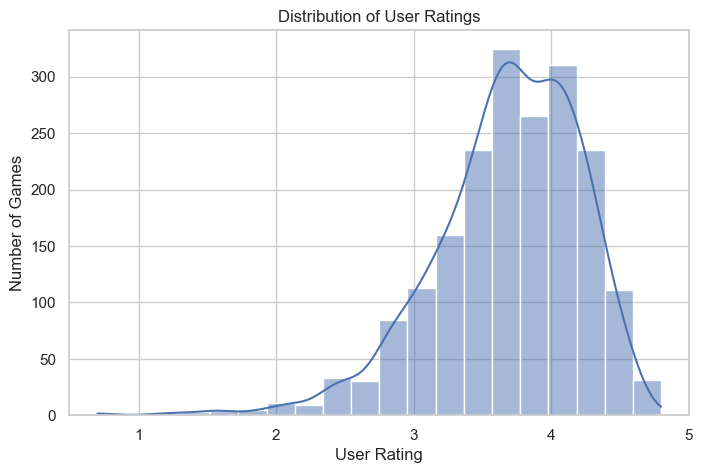

In [42]:
plt.figure(figsize=(8,5))
sns.histplot(games['rating'], bins=20, kde=True)
plt.title("Distribution of User Ratings")
plt.xlabel("User Rating")
plt.ylabel("Number of Games")
plt.show()

##### Insight:
User ratings are heavily concentrated between 3.5 and 4.5, indicating that most games receive positive feedback, with very few poorly rated titles.

#### Chart 2: Most Common Game Genres (Bar chart (Top 10))
Question: What are the most common genres in the dataset?

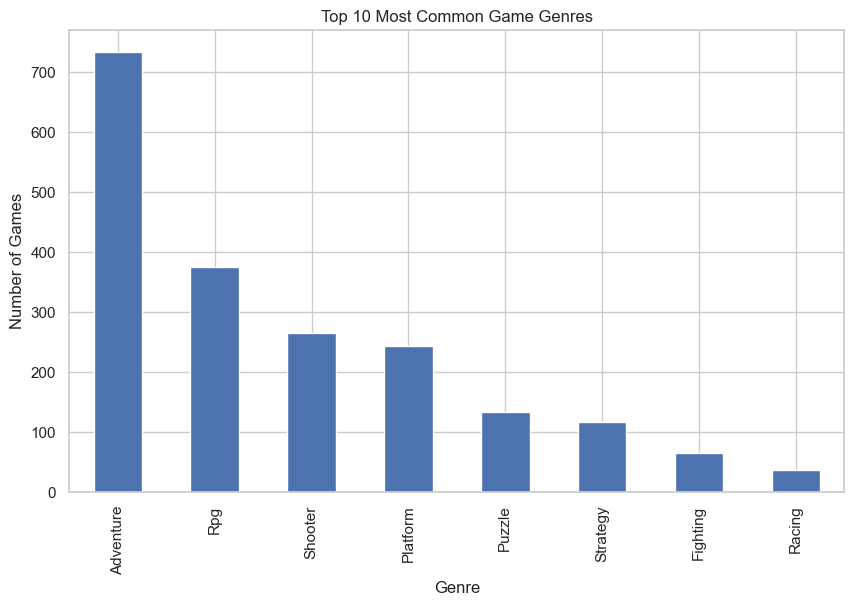

In [43]:
plt.figure(figsize=(10,6))
games['genres'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Most Common Game Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Games")
plt.show()


##### Insight:
A small number of genres (such as Action, RPG, and Adventure) dominate the dataset, suggesting market saturation and high competition in these categories.

#### Chart 3: Backlog vs Wishlist (Top Games)
Question: Which games have the highest backlog compared to wishlist?

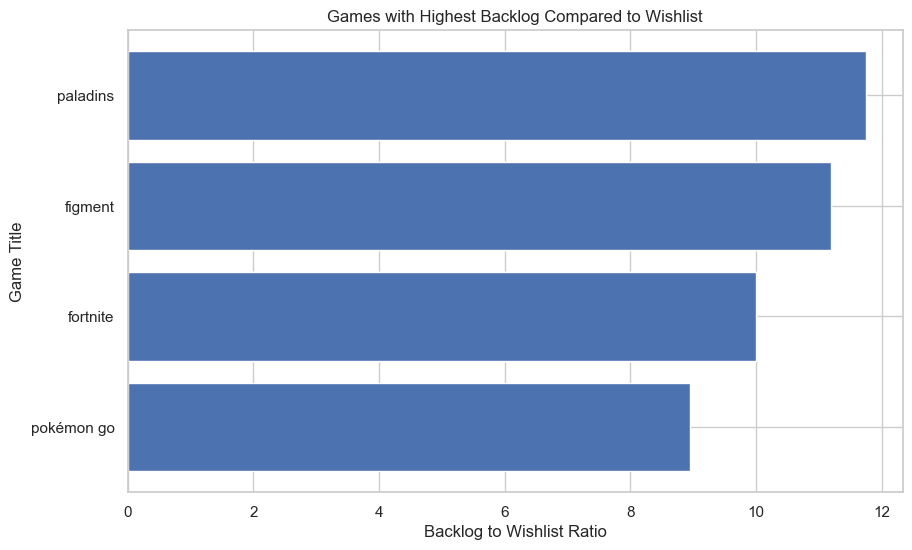

In [44]:
games['backlogs'] = pd.to_numeric(games['backlogs'], errors='coerce')
games['wishlist'] = pd.to_numeric(games['wishlist'], errors='coerce')

# Avoid division by zero
filtered_games = games[(games['wishlist'] > 0) & (games['backlogs'].notna())]

# Create backlog to wishlist ratio
filtered_games['backlog_wishlist_ratio'] = (
    filtered_games['backlogs'] / filtered_games['wishlist']
)

# Select top 10 games with highest backlog relative to wishlist
top_backlog_games = (
    filtered_games.sort_values('backlog_wishlist_ratio', ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(10,6))
plt.barh(
    top_backlog_games['title'],
    top_backlog_games['backlog_wishlist_ratio']
)
plt.xlabel("Backlog to Wishlist Ratio")
plt.ylabel("Game Title")
plt.title("Games with Highest Backlog Compared to Wishlist")
plt.gca().invert_yaxis()
plt.show()

##### Insight:
Game releases show a steady upward trend over time, reflecting industry growth and increasing ease of game development and distribution.

#### Chart 4. Distribution of Number of Plays (Histogram)
Question: How are play counts distributed?

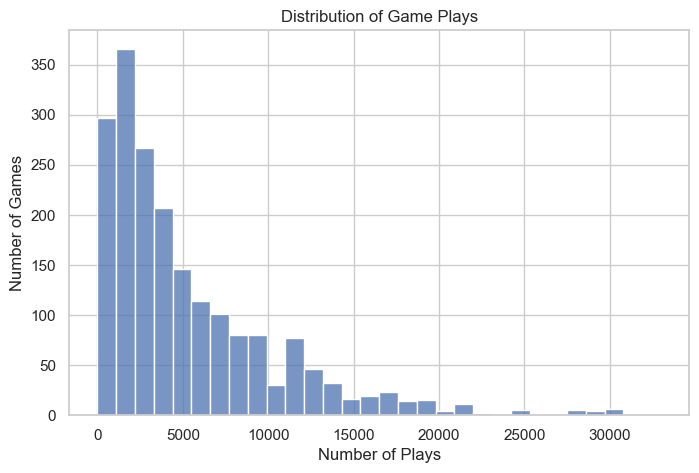

In [45]:
plt.figure(figsize=(8,5))
sns.histplot(games['plays'], bins=30)
plt.title("Distribution of Game Plays")
plt.xlabel("Number of Plays")
plt.ylabel("Number of Games")
plt.show()


##### Insight:
The distribution is strongly right-skewed, indicating that only a small fraction of games achieve very high engagement, while most games have relatively low play counts.

#### Chart 5. Distribution of Wishlist Counts (Histogram) 
Question:How many games attract high user interest?

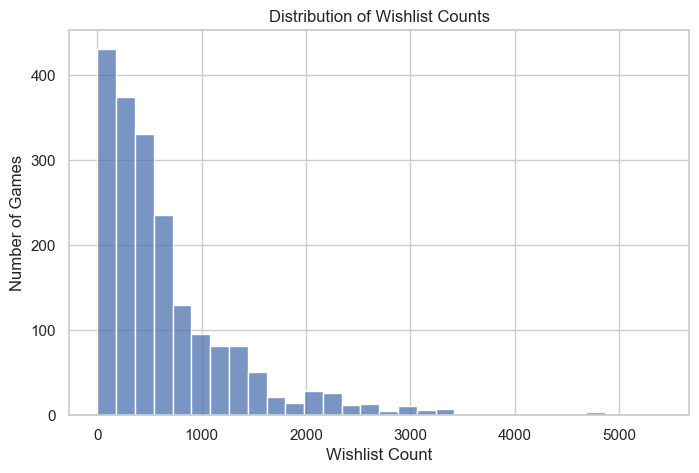

In [46]:
plt.figure(figsize=(8,5))
sns.histplot(games['wishlist'], bins=30)
plt.title("Distribution of Wishlist Counts")
plt.xlabel("Wishlist Count")
plt.ylabel("Number of Games")
plt.show()


##### Insight:
Most games have low wishlist counts, while a few titles receive exceptionally high interest, highlighting strong user anticipation concentrated in limited games.

#### Chart 6:Total Sales by Region (Bar chart)
Question: Which region generates the most game sales??

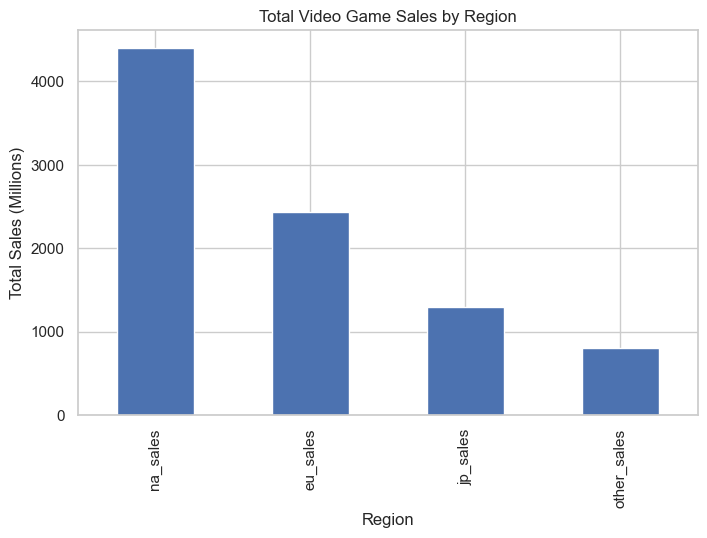

In [47]:
plt.figure(figsize=(8,5))
region_sales = vgsales[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()
region_sales.plot(kind='bar')
plt.title("Total Video Game Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales (Millions)")
plt.show()

##### Insight:
North America generates the highest total sales, followed by Europe, indicating that Western markets dominate global video game revenue.

#### Chart 7:Number of Games per Platform (Bar chart)
Question: Which platforms have the most games?

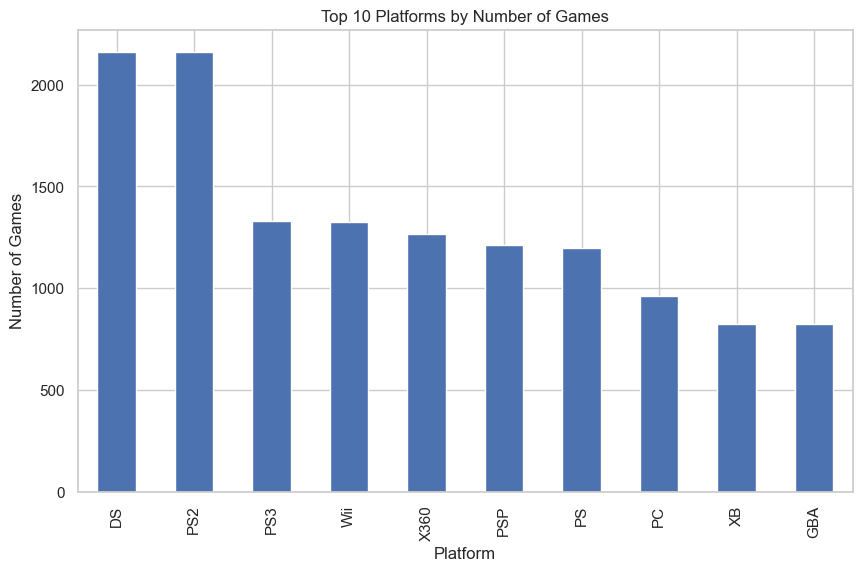

In [48]:
plt.figure(figsize=(10,6))
vgsales['platform'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Platforms by Number of Games")
plt.xlabel("Platform")
plt.ylabel("Number of Games")
plt.show()


##### Insight:
A few platforms host a large number of games, suggesting platform dominance and higher developer adoption on these systems.

#### Chart 8. Distribution of Combined User Ratings (Histogram)
Question: What is the rating distribution after merging datasets?

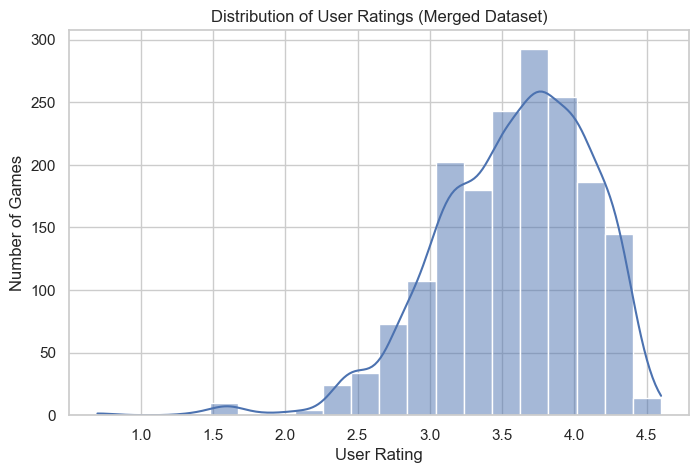

In [49]:
plt.figure(figsize=(8,5))
sns.histplot(merged_df['rating'], bins=20, kde=True)
plt.title("Distribution of User Ratings (Merged Dataset)")
plt.xlabel("User Rating")
plt.ylabel("Number of Games")
plt.show()


##### Insight:
The merged dataset maintains a rating distribution similar to the original games dataset, confirming that the merge process did not introduce bias.

#### Chart 9. Distribution of Global Sales (Merged Dataset) (Histogram)
Question: How do sales behave in the merged dataset?

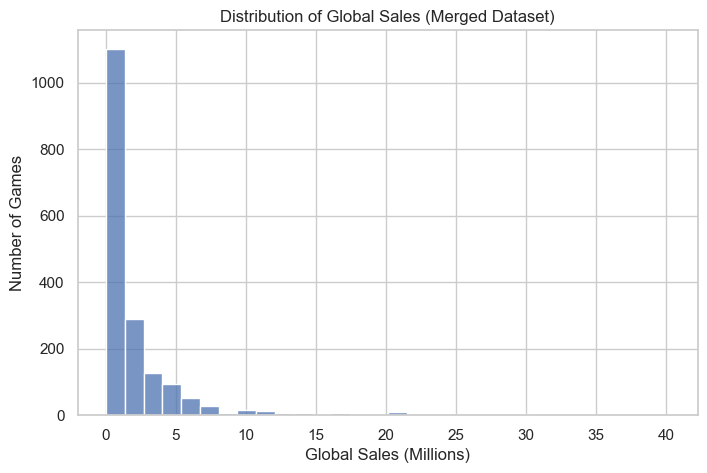

In [50]:
plt.figure(figsize=(8,5))
sns.histplot(merged_df['global_sales'], bins=30)
plt.title("Distribution of Global Sales (Merged Dataset)")
plt.xlabel("Global Sales (Millions)")
plt.ylabel("Number of Games")
plt.show()


##### Insight:
Global sales remain heavily skewed toward a small subset of games, reinforcing the blockbuster-driven nature of the video game market.

### BIVARIATE ANALYSIS

(Two variables — comparison & relationships)

#### Chart 10. TOP 10 Highest Rated Games
Question: What are the top-rated games by user reviews?

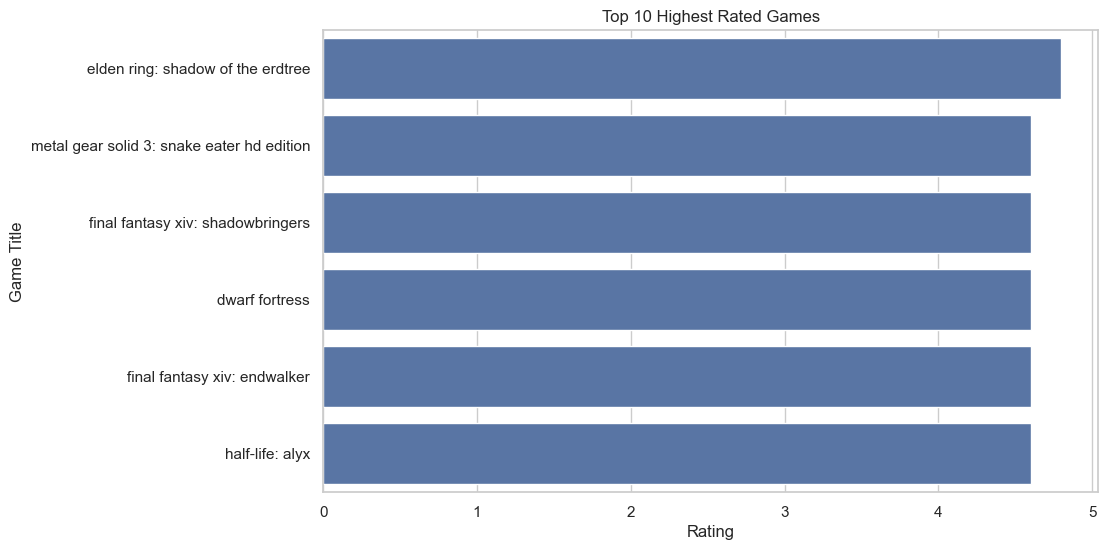

In [51]:
top_rated = games.sort_values('rating', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='rating', y='title', data=top_rated)
plt.title("Top 10 Highest Rated Games")
plt.xlabel("Rating")
plt.ylabel("Game Title")
plt.show()


Insight:
Top-rated games show minimal rating variation, indicating a ceiling effect in user scoring.

#### Chart 11. TOP Developers by Average Ratings
Question: Which developers have the highest average ratings?

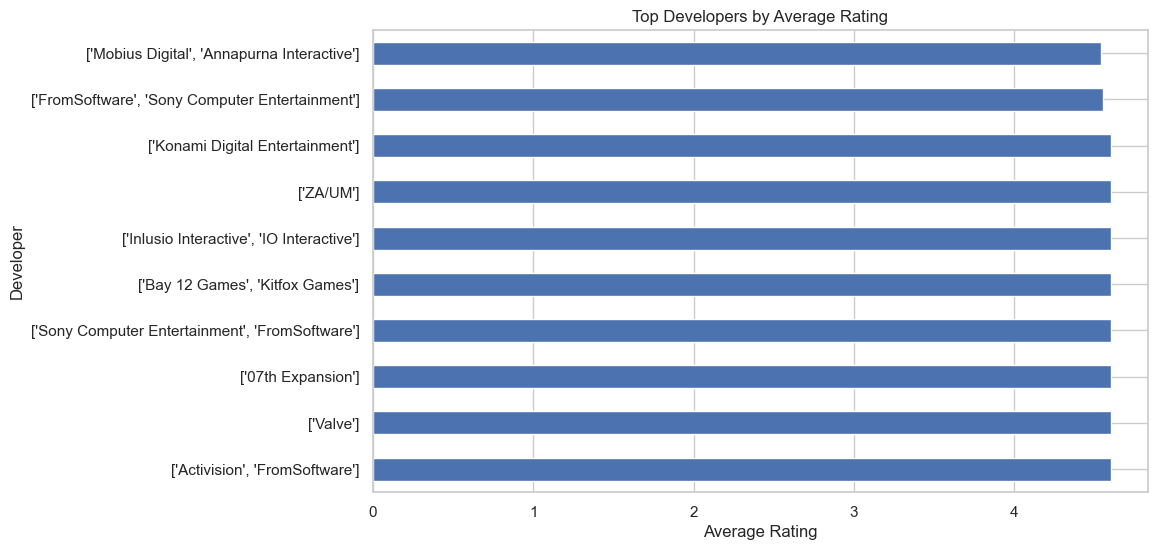

In [52]:
avg_dev_rating = (
    games.groupby('team')['rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
avg_dev_rating.plot(kind='barh')
plt.title("Top Developers by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Developer")
plt.show()


Insight:
Smaller or niche studios often outperform large studios in average ratings, suggesting quality-focused development.

#### Chart 12. Average plays per genre 
Question: What’s the average number of plays per genre?

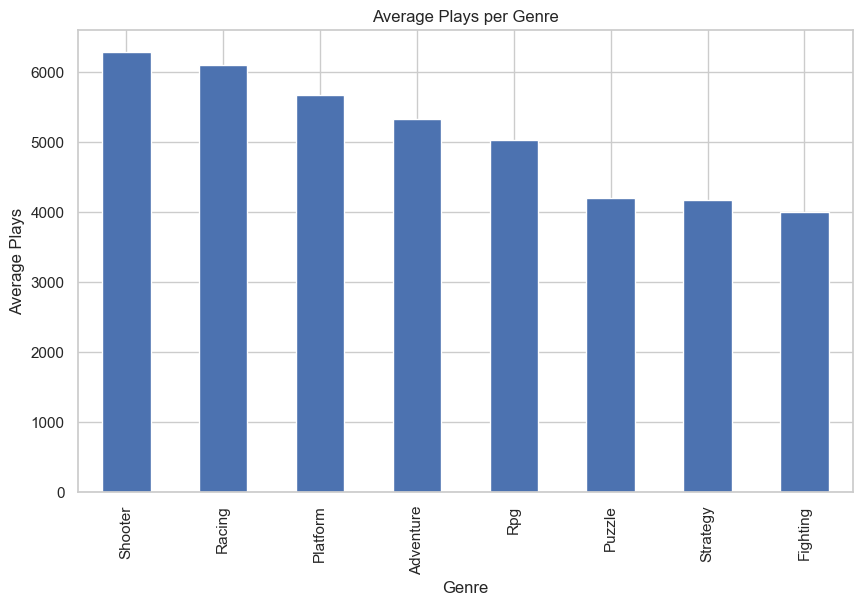

In [53]:
avg_plays = (
    games.groupby('genres')['plays']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
avg_plays.plot(kind='bar')
plt.title("Average Plays per Genre")
plt.xlabel("Genre")
plt.ylabel("Average Plays")
plt.show()


Insight:
Action-oriented genres attract significantly higher engagement compared to narrative-driven genres.

#### Chart 13. Global Sales Trend Over Years 
Question: What’s the trend of game releases and sales over years?

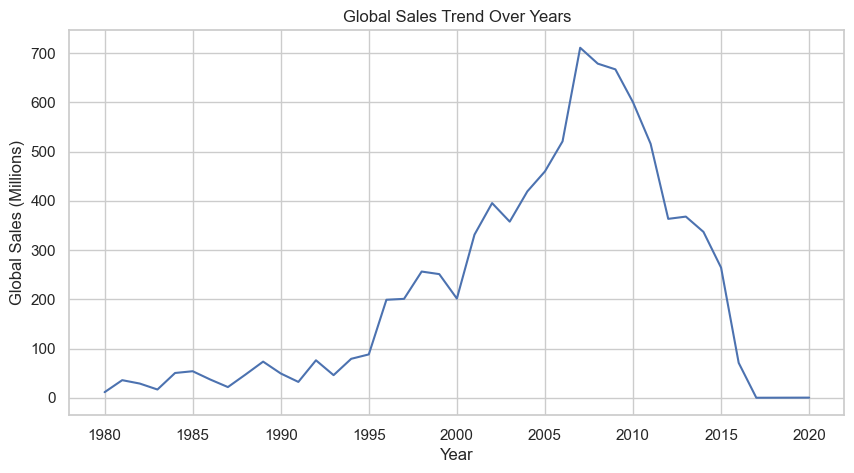

In [54]:
yearly_sales = vgsales.groupby('year')['global_sales'].sum()

plt.figure(figsize=(10,5))
yearly_sales.plot()
plt.title("Global Sales Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.show()


Insight:
Sales peak during major console generations and decline later, indicating platform lifecycle effects.

#### Chart 14. Yearly Sales Trend By Region
Question: What’s the yearly sales change per region?

<Figure size 1000x600 with 0 Axes>

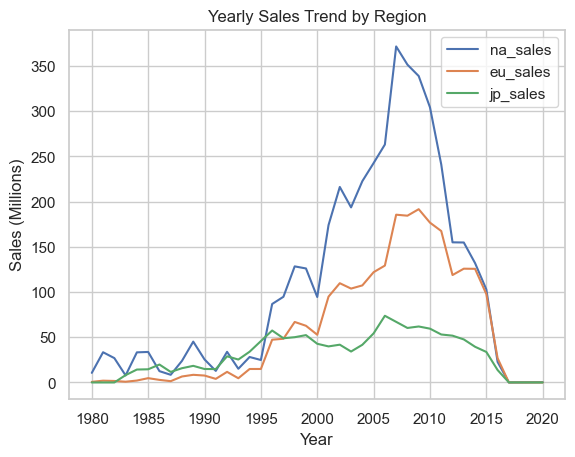

In [55]:
regional_sales = vgsales.groupby('year')[['na_sales','eu_sales','jp_sales']].sum()

plt.figure(figsize=(10,6))
regional_sales.plot()
plt.title("Yearly Sales Trend by Region")
plt.xlabel("Year")
plt.ylabel("Sales (Millions)")
plt.show()


Insight:
Japan shows a declining trend compared to NA and EU, reflecting regional market shifts.

#### Chart 15. User Rating VS Global Sales
Question: How does user rating affect global sales?

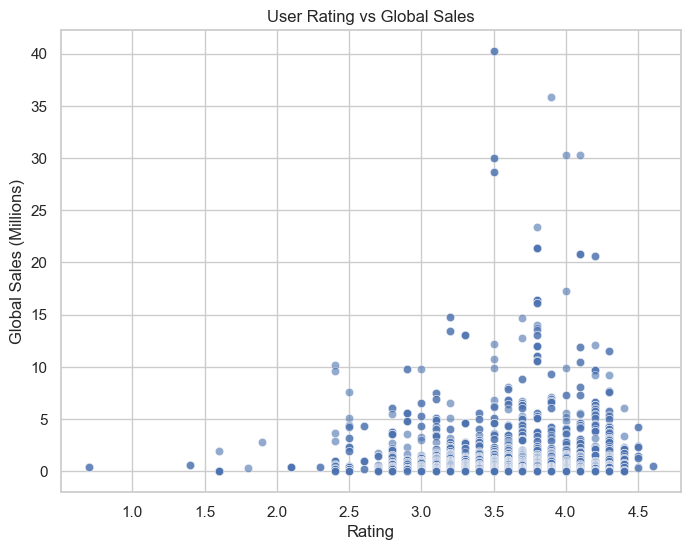

In [56]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='rating',
    y='global_sales',
    data=merged_df,
    alpha=0.6
)
plt.title("User Rating vs Global Sales")
plt.xlabel("Rating")
plt.ylabel("Global Sales (Millions)")
plt.show()


Insight:
Higher ratings slightly increase sales probability, but ratings alone do not guarantee high revenue.

#### Chart 16. Wishlist VS Global Sales
Question: Do highly wishlisted games lead to more sales?

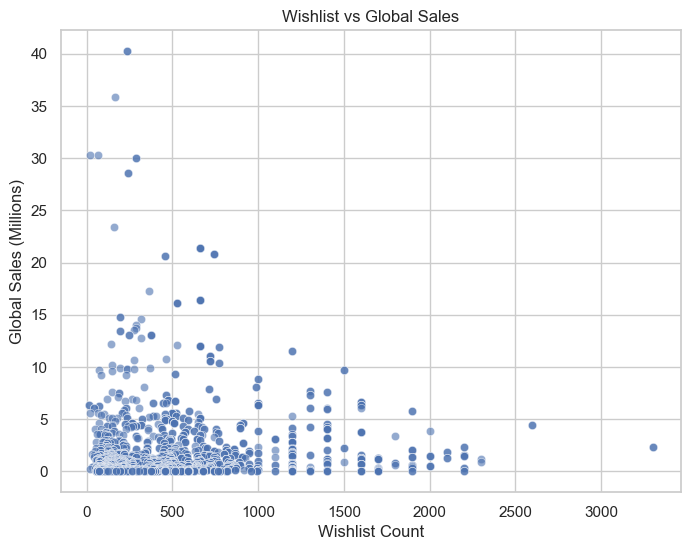

In [57]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='wishlist',
    y='global_sales',
    data=merged_df,
    alpha=0.6
)
plt.title("Wishlist vs Global Sales")
plt.xlabel("Wishlist Count")
plt.ylabel("Global Sales (Millions)")
plt.show()


Insight:
Wishlist count shows a stronger positive relationship with sales than ratings, indicating purchase intent matters more.

### MULTIVARIATE ANALYSIS

(3+ variables — deeper behavioral insights)

#### Chart 17. Wishlist VS Global Sales
Question: Do highly listed games (wishlist/backlogs) correlate with better ratings?

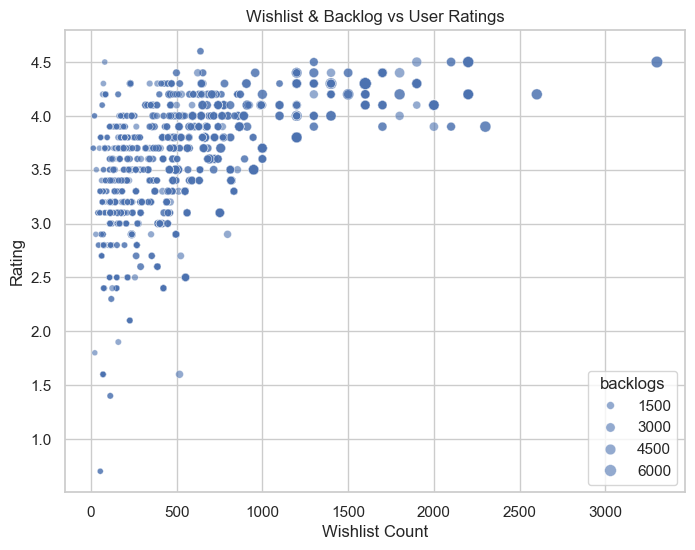

In [58]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='wishlist',
    y='rating',
    size='backlogs',
    data=merged_df,
    alpha=0.6
)
plt.title("Wishlist & Backlog vs User Ratings")
plt.xlabel("Wishlist Count")
plt.ylabel("Rating")
plt.show()


Insight:
High anticipation does not always translate into higher ratings, highlighting a hype vs quality gap.

#### Chart 18. Correaltion Heatmap: Engagement Metrics vs Global Sales
Question: How do engagement metrics, ratings, and sales relate to each other?

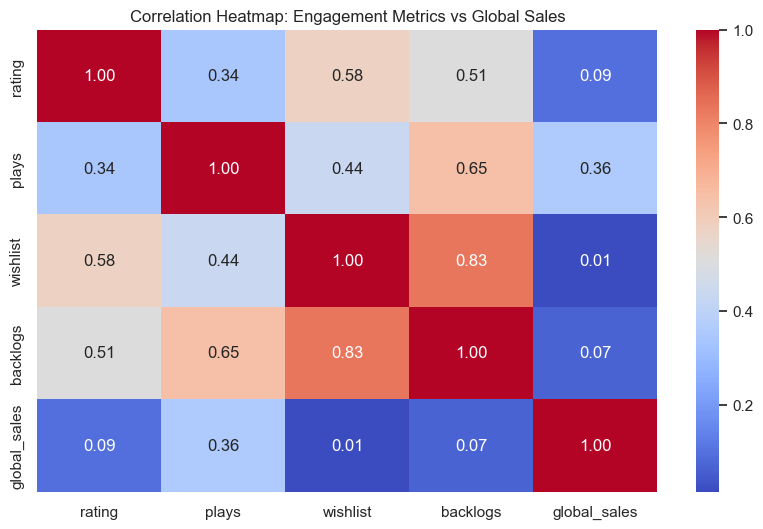

In [59]:
plt.figure(figsize=(10,6))

corr_matrix = merged_df[
    ['rating', 'plays', 'wishlist', 'backlogs', 'global_sales']
].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap: Engagement Metrics vs Global Sales")
plt.show()


Insights:
The correlation heatmap reveals that engagement indicators such as wishlists and plays are stronger predictors of sales than ratings, emphasizing the importance of user intent and interaction over perceived quality alone.

## **4. Solution to Business Objective**

To achieve the business objective, the client should focus on aligning high user engagement with monetization strategies. The analysis shows that while user ratings indicate quality, engagement metrics such as wishlists and play counts are stronger drivers of sales. Therefore, marketing and launch strategies should prioritize boosting pre-release interest through wishlists, targeted promotions, and regional campaigns.

Additionally, the client should invest in genre–platform combinations that demonstrate both high engagement and strong sales performance, while addressing genres that show high interest but low conversion through pricing, bundling, or improved distribution. Leveraging regional preferences and platform trends will enable data-driven decisions, helping maximize revenue while maintaining user satisfaction.

# **Conclusion**

This project combined game metadata, user engagement, and sales data to identify key drivers of success in the video game market. The analysis showed that user engagement metrics such as wishlists and play counts have a stronger impact on sales than ratings alone, while regional and genre preferences significantly influence performance. By leveraging Python, SQL, and Power BI, the project demonstrates how data-driven insights can support strategic decisions to improve monetization, targeting, and overall business outcomes.

# **THANK YOU**